In [1]:
pip install ucimlrepo

In [4]:
pip install pytorch_tabnet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 2.6 MB/s eta 0:00:00


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from pytorch_tabnet.tab_model import TabNetClassifier
import torch

# 1. 获取数据集
print("正在从 UCI 获取数据集...")
credit_card_data = fetch_ucirepo(id=350)

# 特征和标签
X = credit_card_data.data.features
y = credit_card_data.data.targets.values.ravel() # 展平为一维数组

# 获取特征名称，稍后可视化要用
feature_names = X.columns.tolist()

print(f"数据加载完成！形状: {X.shape}")

正在从 UCI 获取数据集...
数据加载完成！形状: (30000, 23)


In [6]:
# 2. 划分数据集 (训练集、验证集、测试集)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

# 3. 标准化 (注意：TabNet 也可以直接处理原始数据，但标准化通常效果更好)
scaler = StandardScaler()
X_train_np = scaler.fit_transform(X_train)
X_val_np = scaler.transform(X_val)
X_test_np = scaler.transform(X_test)

print("数据预处理完毕。")

数据预处理完毕。


In [11]:
# 4. 初始化 TabNet 分类器
clf = TabNetClassifier(
    optimizer_fn=torch.optim.Adam,
    optimizer_params=dict(lr=2e-2),
    scheduler_params={"step_size":10, "gamma":0.9},
    scheduler_fn=torch.optim.lr_scheduler.StepLR,
    mask_type='entmax', # 让 Mask 更加稀疏，突出重点
    verbose=1
)

# 5. 训练模型
clf.fit(
    X_train=X_train_np, y_train=y_train,
    eval_set=[(X_train_np, y_train), (X_val_np, y_val)],
    eval_name=['train', 'valid'],
    eval_metric=['auc'],
    max_epochs=50,
    patience=20,
    batch_size=1024,
    virtual_batch_size=128,
    num_workers=0,
    drop_last=False
)

/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/abstract_model.py:82: UserWarning: Device used : cuda
  warnings.warn(f"Device used : {self.device}")


epoch 0  | loss: 0.60652 | train_auc: 0.70051 | valid_auc: 0.689   |  0:00:01s
epoch 1  | loss: 0.47611 | train_auc: 0.72626 | valid_auc: 0.70985 |  0:00:02s
epoch 2  | loss: 0.45825 | train_auc: 0.74865 | valid_auc: 0.72561 |  0:00:03s
epoch 3  | loss: 0.45184 | train_auc: 0.75687 | valid_auc: 0.7387  |  0:00:05s
epoch 4  | loss: 0.44652 | train_auc: 0.76153 | valid_auc: 0.75091 |  0:00:06s
epoch 5  | loss: 0.4461  | train_auc: 0.76497 | valid_auc: 0.74721 |  0:00:07s
epoch 6  | loss: 0.44586 | train_auc: 0.76304 | valid_auc: 0.73981 |  0:00:09s
epoch 7  | loss: 0.44704 | train_auc: 0.76669 | valid_auc: 0.74422 |  0:00:10s
epoch 8  | loss: 0.44275 | train_auc: 0.77193 | valid_auc: 0.7444  |  0:00:11s
epoch 9  | loss: 0.43912 | train_auc: 0.77027 | valid_auc: 0.74833 |  0:00:12s
epoch 10 | loss: 0.44031 | train_auc: 0.77377 | valid_auc: 0.75345 |  0:00:14s
epoch 11 | loss: 0.4362  | train_auc: 0.7742  | valid_auc: 0.75185 |  0:00:15s
epoch 12 | loss: 0.43737 | train_auc: 0.77451 | vali

/usr/local/lib/python3.12/dist-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)


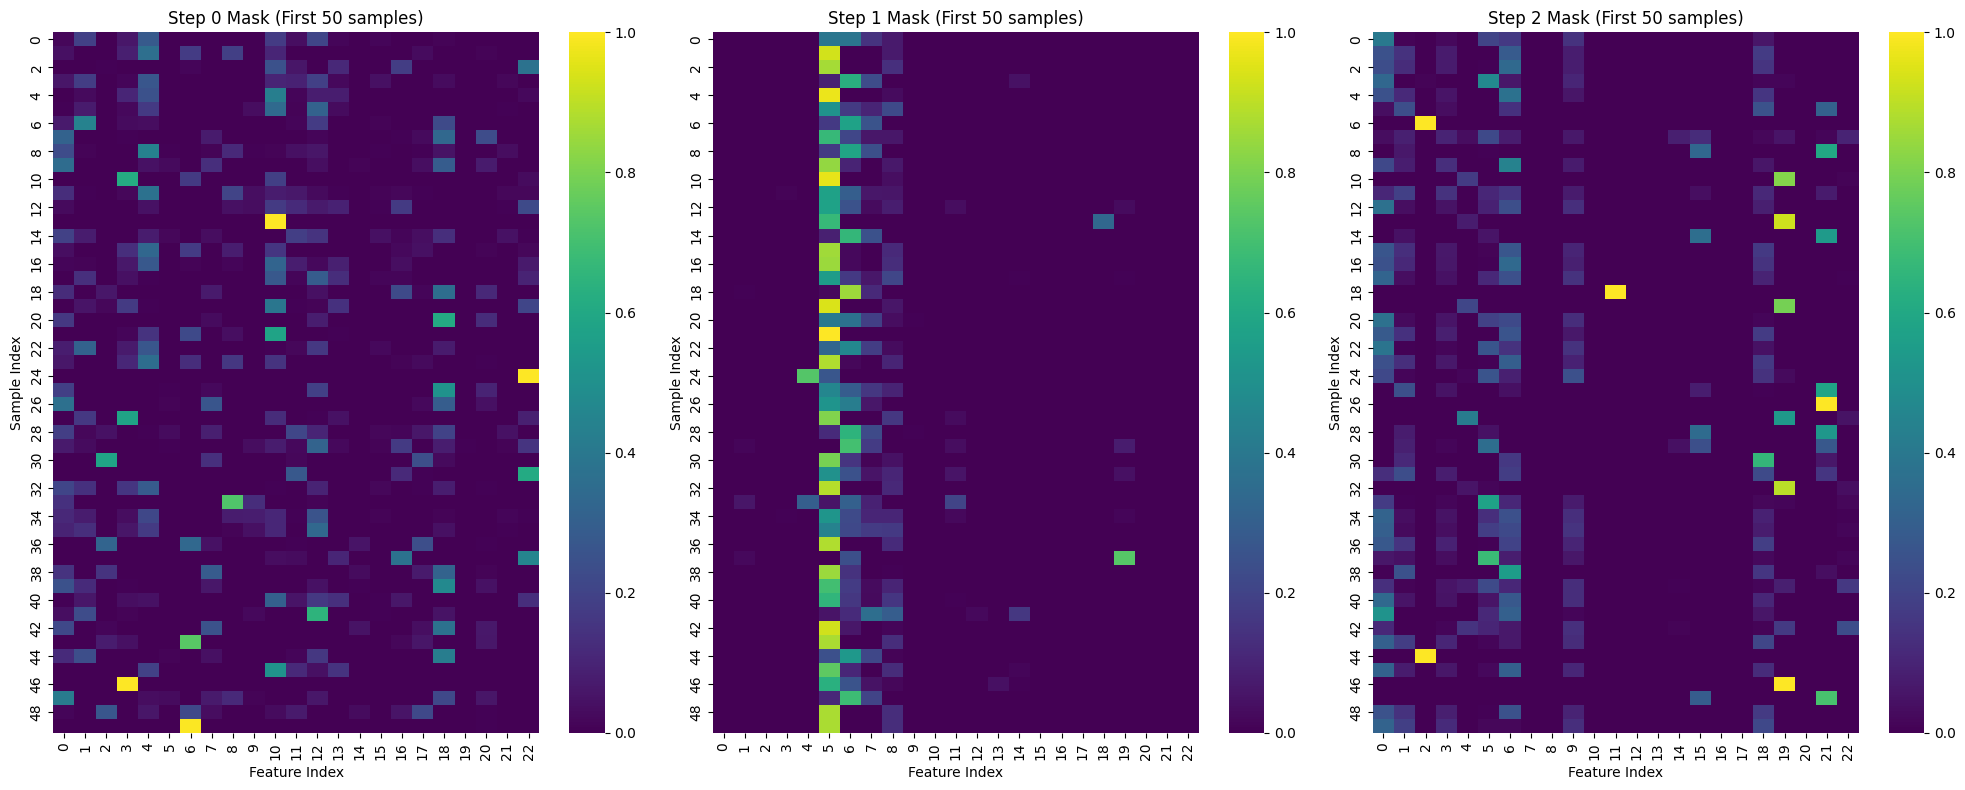

横坐标 0-22 对应数据集中的 23 个特征。


In [13]:
# 6. 提取解释性矩阵和 Mask
explain_matrix, masks = clf.explain(X_test_np)

# 7. 可视化前 3 个步骤的 Mask
fig, axs = plt.subplots(1, 3, figsize=(20, 8))

for i in range(3):
    # 只展示测试集中前 50 个样本的 Mask 变化
    sns.heatmap(masks[i][:50], ax=axs[i], cmap='viridis', cbar=True)
    axs[i].set_title(f"Step {i} Mask (First 50 samples)")
    axs[i].set_xlabel("Feature Index")
    axs[i].set_ylabel("Sample Index")

plt.tight_layout()
plt.show()

print("横坐标 0-22 对应数据集中的 23 个特征。")

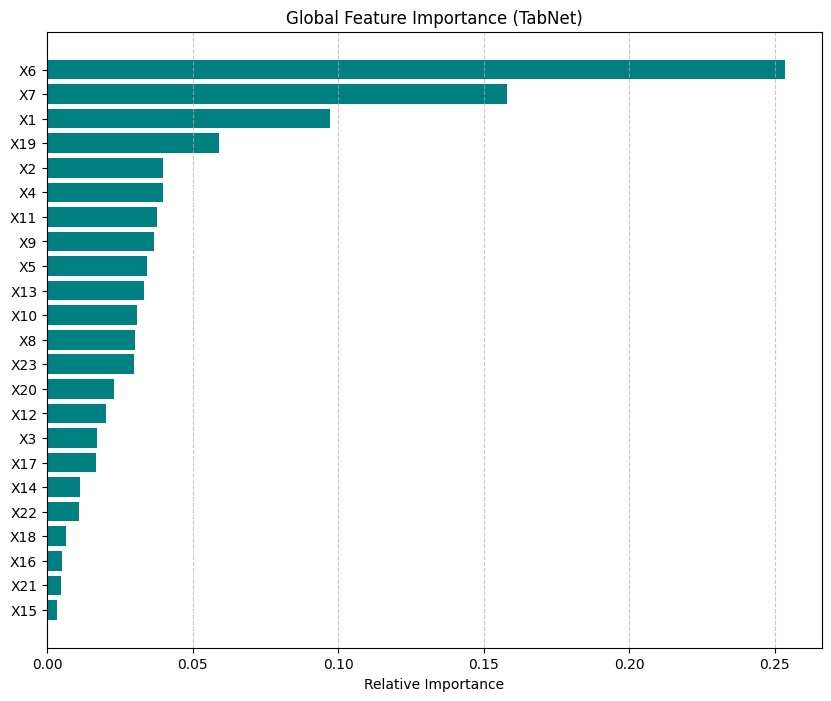

In [14]:
# 8. 绘制全局特征重要性
prioritized_features = clf.feature_importances_
indices = np.argsort(prioritized_features)

plt.figure(figsize=(10, 8))
plt.title("Global Feature Importance (TabNet)")
plt.barh(range(len(indices)), prioritized_features[indices], color='teal', align='center')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel('Relative Importance')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()